In [12]:
!pip install opencv-python --user

In [31]:
#Import necessary libraries
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [14]:
#Sets up the file paths and labels.
data_path = r'C:\Users\User\OneDrive\Desktop\SLIIT Modules\AIML\Face Recognition\FER_Custom_Dataset'

categories = os.listdir(data_path)
print(categories)

['Disappointed', 'interested', 'neutral']


In [15]:
label = np.arange(len(categories))
print(label)

[0 1 2]


In [16]:
label_dict = dict(zip(categories, label))
print(label_dict)

{'Disappointed': np.int64(0), 'interested': np.int64(1), 'neutral': np.int64(2)}


In [17]:
#Image Processing Loop (Resizing and Color Space Conversion)

data = []
target= []

img_size = 50

for category in categories:
    img_paths = os.path.join(data_path, category)
    img_names = os.listdir(img_paths)
    
    for img_name in img_names:
        img_path = os.path.join(img_paths, img_name)
        try:
            original_img = cv2.imread(img_path)

            if original_img is None:
                print("Failed to load:", img_path)
                continue

            gray_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
            processed_img = cv2.resize(gray_img, (img_size, img_size))
            
            data.append(processed_img)
            target.append(label_dict[category])

        except Exception as e:
            print("Error with image:", img_path, e)

In [18]:
data_new = np.array(data)
print(data_new.shape)

(43819, 50, 50)


In [19]:
target_new = np.array(target)
print(target_new.shape)

(43819,)


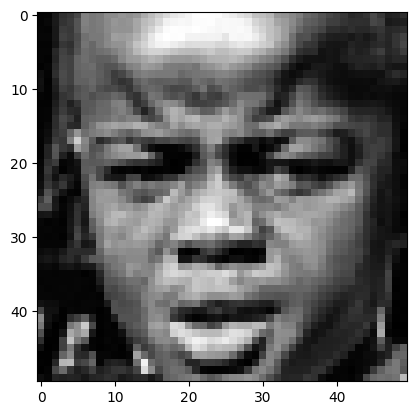

In [33]:
#Show gray image
plt.imshow(data[0], cmap = 'gray')

In [21]:
target[0]

np.int64(0)

In [23]:
#converting to 4D, coz' CNN need 4D input
data_new = data_new.reshape(data_new.shape[0],data_new.shape[1],data_new.shape[2],1) 
print(data_new.shape)

(43819, 50, 50, 1)


In [24]:
np.save('data', data_new)
np.save('target', target_new)

In [ ]:
# ----------- EDA Visualization -----------

In [39]:
original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

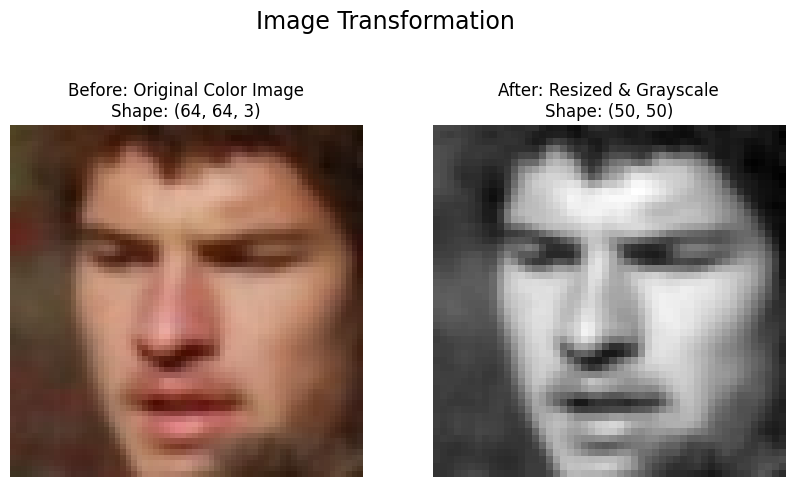

In [40]:
plt.figure(figsize=(10, 6))

# Display Before Image
plt.subplot(1, 2, 1)
plt.imshow(original_img_rgb)
plt.title(f'Before: Original Color Image\nShape: {original_img_rgb.shape}')
plt.axis('off')

# Display After Processed Image
plt.subplot(1, 2, 2)
plt.imshow(processed_img, cmap='gray')
plt.title(f'After: Resized & Grayscale\nShape: {processed_img.shape}')
plt.axis('off')

plt.suptitle('Image Transformation', fontsize=17)
plt.show()

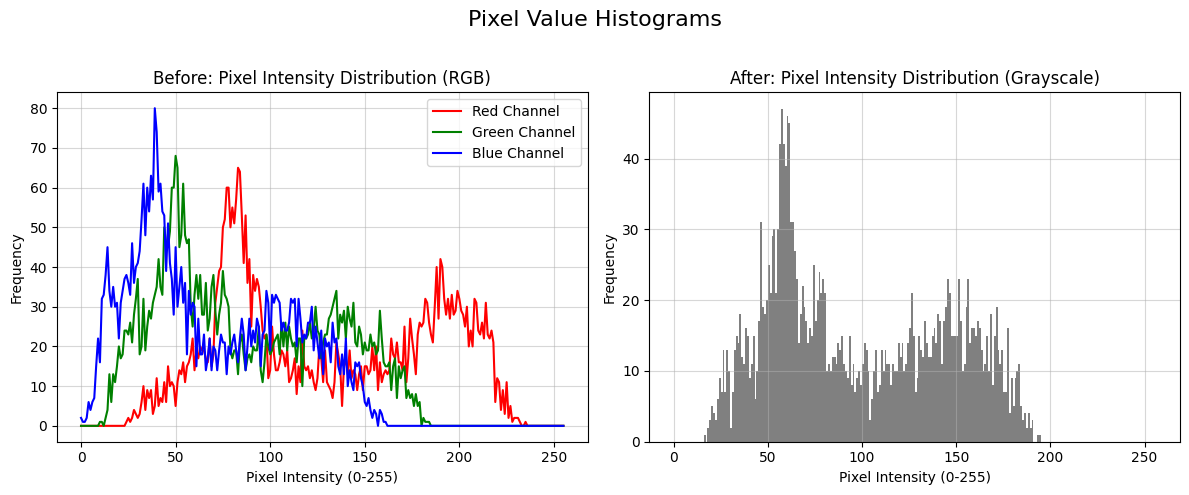

In [38]:
# Create a figure to display the histograms
plt.figure(figsize=(12, 5))

# --- Before: Histogram of the original color image ---
plt.subplot(1, 2, 1)
colors = ('r', 'g', 'b')
for i, color in enumerate(colors):
    histogram = cv2.calcHist([original_img_rgb], [i], None, [256], [0, 256])
    plt.plot(histogram, color=color)
plt.title('Before: Pixel Intensity Distribution (RGB)')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.5)
plt.legend(['Red Channel', 'Green Channel', 'Blue Channel'])

# --- After: Histogram of the processed grayscale image ---
plt.subplot(1, 2, 2)
plt.hist(processed_img.flatten(), bins=256, range=[0, 256], color='gray')
plt.title('After: Pixel Intensity Distribution (Grayscale)')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.5)

plt.suptitle('Pixel Value Histograms', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()